# Phase 8 — Evaluation, Regularization Sweeps & Coefficient Plots

Compare L2 models across regularization strengths, plot Precision–Recall curves, and inspect the top text vs tabular coefficients that drive funding predictions.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
PROC = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

C_GRID = [0.01, 0.1, 1.0, 10.0]
RANDOM_STATE = 42
TOP_N = 15

## 1. Load fused matrices

In [2]:
X_train = sparse.load_npz(PROC / "X_train_fused.npz").tocsr()
X_test = sparse.load_npz(PROC / "X_test_fused.npz").tocsr()
y_train = np.load(PROC / "y_train.npy")
y_test = np.load(PROC / "y_test.npy")
feature_names = pd.read_csv(PROC / "fused_feature_names.csv")["feature"].astype(str).to_numpy()

print(f"train {X_train.shape} | test {X_test.shape}")

train (264728, 2713) | test (66183, 2713)


## 2. Regularization strength sweep (L2)

Smaller `C` = stronger L2 penalty. Track Precision / Recall / Accuracy / F1 on the test set.

In [3]:
def score_model(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
        "roc_auc": roc_auc_score(y, proba),
        "average_precision": average_precision_score(y, proba),
        "proba": proba,
        "model": model,
    }


rows = []
fitted = {}

for C in C_GRID:
    model = LogisticRegression(
        penalty="l2",
        C=C,
        solver="liblinear",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train, y_train)
    train_scores = score_model(model, X_train, y_train)
    test_scores = score_model(model, X_test, y_test)
    fitted[C] = test_scores
    rows.append(
        {
            "penalty": "l2",
            "C": C,
            "split": "train",
            **{k: train_scores[k] for k in ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]},
        }
    )
    rows.append(
        {
            "penalty": "l2",
            "C": C,
            "split": "test",
            **{k: test_scores[k] for k in ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision"]},
        }
    )

metrics_df = pd.DataFrame(rows).round(4)
test_table = metrics_df[metrics_df["split"] == "test"].drop(columns="split").reset_index(drop=True)
test_table

/Users/koriginjasathvik/Desktop/ML_Summer_Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/Users/koriginjasathvik/Desktop/ML_Summer_Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/Users/koriginjasathvik/Desktop/ML_Summer_Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


/Users/koriginjasathvik/Desktop/ML_Summer_Project/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,penalty,C,accuracy,precision,recall,f1,roc_auc,average_precision
0,l2,0.01,0.6769,0.6494,0.4349,0.5209,0.7195,0.6245
1,l2,0.10,0.6893,0.6523,0.4943,0.5624,0.7384,0.6448
2,l2,1.00,0.6898,0.6454,0.5149,0.5728,0.7407,0.6476
3,l2,10.00,0.6898,0.6440,0.5189,0.5747,0.7404,0.6473


### What this table shows

As `C` grows, the model fits freer weights. Watch whether test F1 rises then flattens or drops — the “best” C is the one with strong test F1/AP without a large train–test gap.

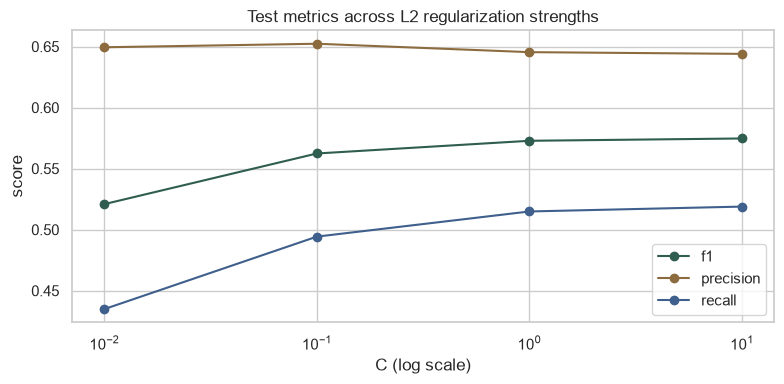

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = metrics_df[metrics_df["split"] == "test"]
for metric, color in [("f1", "#2f5d50"), ("precision", "#8c6b3f"), ("recall", "#3f5f8c")]:
    ax.plot(plot_df["C"], plot_df[metric], marker="o", label=metric, color=color)
ax.set_xscale("log")
ax.set_xlabel("C (log scale)")
ax.set_ylabel("score")
ax.set_title("Test metrics across L2 regularization strengths")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "08_regularization_sweep_metrics.png", dpi=150)
plt.show()

## 3. Precision–Recall curves

best test F1 at C=10.0


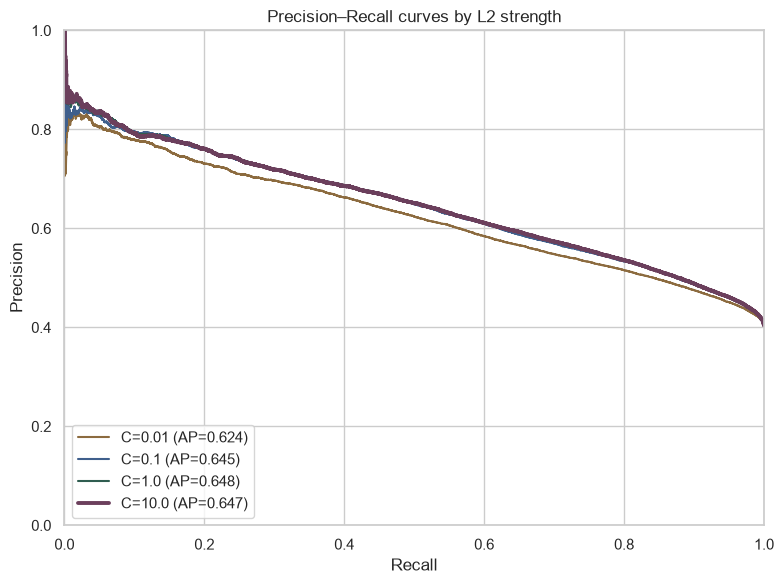

In [5]:
best_C = test_table.sort_values("f1", ascending=False).iloc[0]["C"]
print(f"best test F1 at C={best_C}")

fig, ax = plt.subplots(figsize=(8, 6))
for C, color in zip(C_GRID, ["#8c6b3f", "#3f5f8c", "#2f5d50", "#6b3f5c"]):
    proba = fitted[C]["proba"]
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = fitted[C]["average_precision"]
    lw = 2.8 if C == best_C else 1.5
    ax.plot(recall, precision, color=color, linewidth=lw, label=f"C={C} (AP={ap:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall curves by L2 strength")
ax.legend(loc="lower left")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
fig.savefig(FIG_DIR / "08_precision_recall_curves.png", dpi=150)
plt.show()

### What this figure shows

Each curve trades precision against recall as the probability threshold moves. Higher Average Precision (AP) means better ranking of likely-successful campaigns across thresholds — useful when 0.5 is not the business operating point.

## 4. Top text and tabular coefficients (best F1 model)

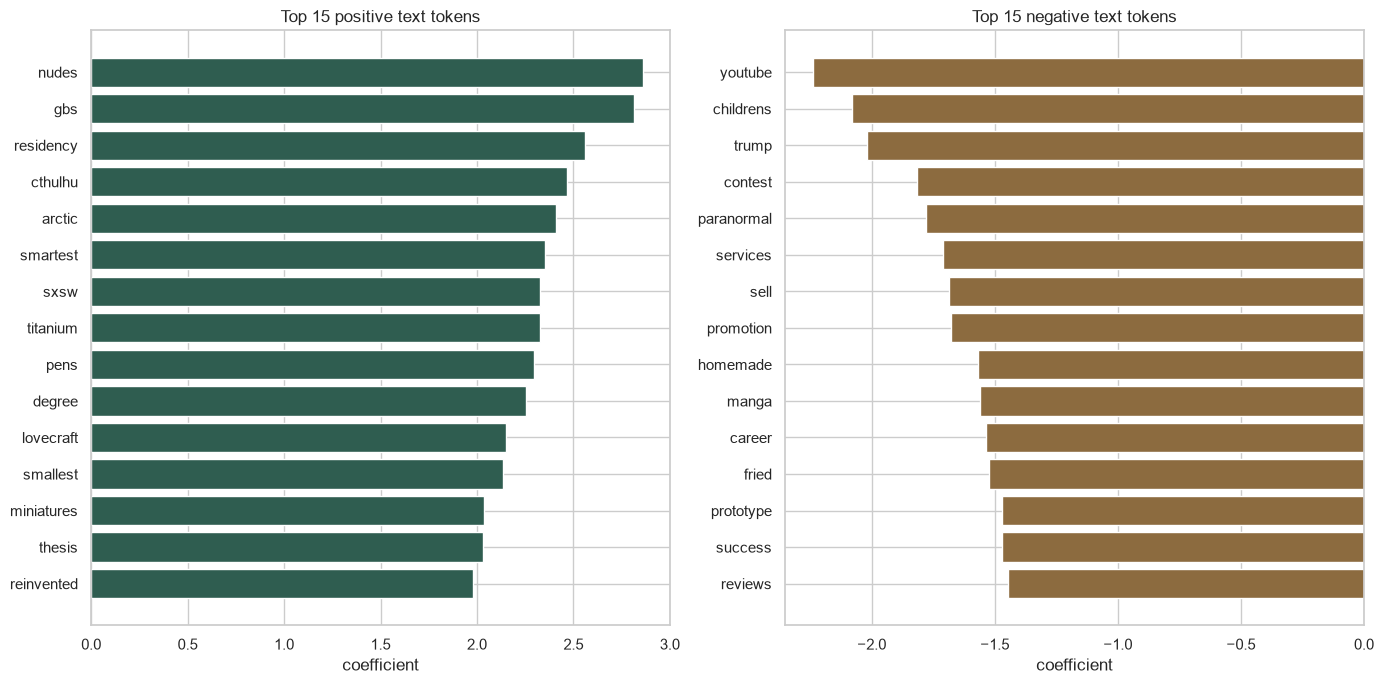

In [6]:
best_model = fitted[best_C]["model"]
coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coef": best_model.coef_.ravel(),
    }
)
coef_df["modality"] = np.where(coef_df["feature"].str.startswith("text__"), "text", "tabular")
coef_df["label"] = coef_df["feature"].str.replace(r"^(text__|tab__)", "", regex=True)

text_coef = coef_df[coef_df["modality"] == "text"].copy()
tab_coef = coef_df[coef_df["modality"] == "tabular"].copy()

text_pos = text_coef.sort_values("coef", ascending=False).head(TOP_N)
text_neg = text_coef.sort_values("coef", ascending=True).head(TOP_N)
tab_top = tab_coef.reindex(tab_coef["coef"].abs().sort_values(ascending=False).index).head(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

pos_plot = text_pos.iloc[::-1]
axes[0].barh(pos_plot["label"], pos_plot["coef"], color="#2f5d50")
axes[0].set_title(f"Top {TOP_N} positive text tokens")
axes[0].set_xlabel("coefficient")

neg_plot = text_neg.iloc[::-1]
axes[1].barh(neg_plot["label"], neg_plot["coef"], color="#8c6b3f")
axes[1].set_title(f"Top {TOP_N} negative text tokens")
axes[1].set_xlabel("coefficient")

plt.tight_layout()
fig.savefig(FIG_DIR / "08_top_text_coefficients.png", dpi=150)
plt.show()

### What these text plots show

Positive tokens push predicted success up; negative tokens push it down. Because titles are short, these words are thematic cues the model leaned on under L2 shrinkage.

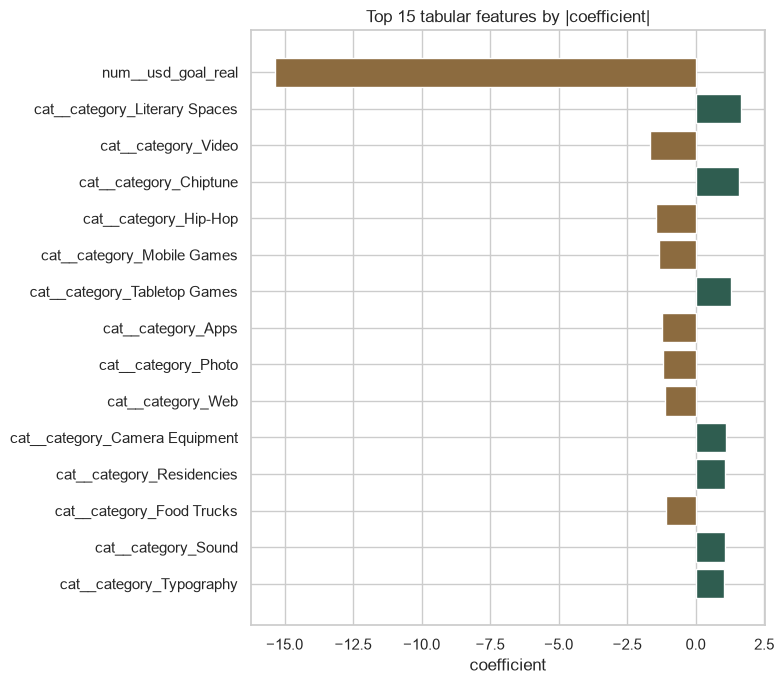

,label,coef
2500,num__usd_goal_real,-15.3646
2585,cat__category_Literary Spaces,1.6695
2648,cat__category_Video,-1.6546
2523,cat__category_Chiptune,1.5895
2570,cat__category_Hip-Hop,-1.4301
2590,cat__category_Mobile Games,-1.3215
2638,cat__category_Tabletop Games,1.2914
2510,cat__category_Apps,-1.2188
2604,cat__category_Photo,-1.2069
2653,cat__category_Web,-1.1300


In [7]:
fig, ax = plt.subplots(figsize=(8, 7))
tab_plot = tab_top.iloc[::-1]
colors = np.where(tab_plot["coef"] >= 0, "#2f5d50", "#8c6b3f")
ax.barh(tab_plot["label"], tab_plot["coef"], color=colors)
ax.set_title(f"Top {TOP_N} tabular features by |coefficient|")
ax.set_xlabel("coefficient")
plt.tight_layout()
fig.savefig(FIG_DIR / "08_top_tabular_coefficients.png", dpi=150)
plt.show()

tab_top[["label", "coef"]].round(4)

### What this tabular plot shows

Strong tabular weights are usually category/country flags or scaled goal/duration. Together with the text plots, this is the multi-modal “what drives predictions” view required by the handbook.

## 5. Save evaluation artifacts

In [8]:
metrics_df.to_csv(PROC / "eval_regularization_metrics.csv", index=False)
test_table.to_csv(PROC / "eval_test_metrics_by_C.csv", index=False)
coef_df.to_csv(PROC / "eval_best_coefficients.csv", index=False)
text_pos.to_csv(PROC / "eval_top_positive_text.csv", index=False)
text_neg.to_csv(PROC / "eval_top_negative_text.csv", index=False)
tab_top.to_csv(PROC / "eval_top_tabular.csv", index=False)

joblib.dump(best_model, PROC / "model_logreg_l2_best.joblib")

meta = {
    "C_grid": C_GRID,
    "best_C_by_test_f1": float(best_C),
    "best_test_metrics": test_table[test_table["C"] == best_C].iloc[0].drop(labels=["penalty"]).to_dict(),
    "figures": [
        "08_regularization_sweep_metrics.png",
        "08_precision_recall_curves.png",
        "08_top_text_coefficients.png",
        "08_top_tabular_coefficients.png",
    ],
}
with open(PROC / "eval_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("saved evaluation artifacts")
meta

saved evaluation artifacts


{'C_grid': [0.01, 0.1, 1.0, 10.0],
 'best_C_by_test_f1': 10.0,
 'best_test_metrics': {'C': 10.0,
  'accuracy': 0.6898,
  'precision': 0.644,
  'recall': 0.5189,
  'f1': 0.5747,
  'roc_auc': 0.7404,
  'average_precision': 0.6473},
 'figures': ['08_regularization_sweep_metrics.png',
  '08_precision_recall_curves.png',
  '08_top_text_coefficients.png',
  '08_top_tabular_coefficients.png']}

## Phase 8 takeaways

- Compared L2 models across `C ∈ {0.01, 0.1, 1.0, 10.0}`.
- Precision–Recall curves + Average Precision recorded per strength.
- Top 15 ± text tokens and strongest tabular weights plotted.
- Notes: [`docs/evaluation.md`](../docs/evaluation.md).